In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt     
import seaborn as sns
sns.set_theme(style="whitegrid")

In [2]:
final_df=pd.read_csv('Final_Cleaned_Dataset_with_sorting.csv')

In [3]:
final_df.head(4)

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session,category_code_filled,brand_filled,hour
0,2019-11-02 13:29:04+00:00,view,12300059,2053013556311359947,construction.tools.drill,bosch,69.17,513196170,00000510-834a-498a-9bed-561a90c5125e,construction.tools.drill,bosch,13
1,2019-11-01 19:06:53+00:00,view,1002544,2053013555631882655,electronics.smartphone,apple,458.25,514001239,000009c4-a1dd-4764-87d9-24f3d7e43c4f,electronics.smartphone,apple,19
2,2019-11-01 19:07:11+00:00,view,1002544,2053013555631882655,electronics.smartphone,apple,458.25,514001239,000009c4-a1dd-4764-87d9-24f3d7e43c4f,electronics.smartphone,apple,19
3,2019-11-01 19:08:13+00:00,view,1004659,2053013555631882655,electronics.smartphone,samsung,716.76,514001239,000009c4-a1dd-4764-87d9-24f3d7e43c4f,electronics.smartphone,samsung,19


Total Number of Users mein se kitne Convert hojaate h and Kitne Cheeze Khareedhte h

C:\Users\asus\AppData\Local\Temp\ipykernel_19812\3525705505.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Action Taken by User', y='Unique Users Count', data=population_funnel, palette=['#4C72B0', '#DD8452', '#55A868'])


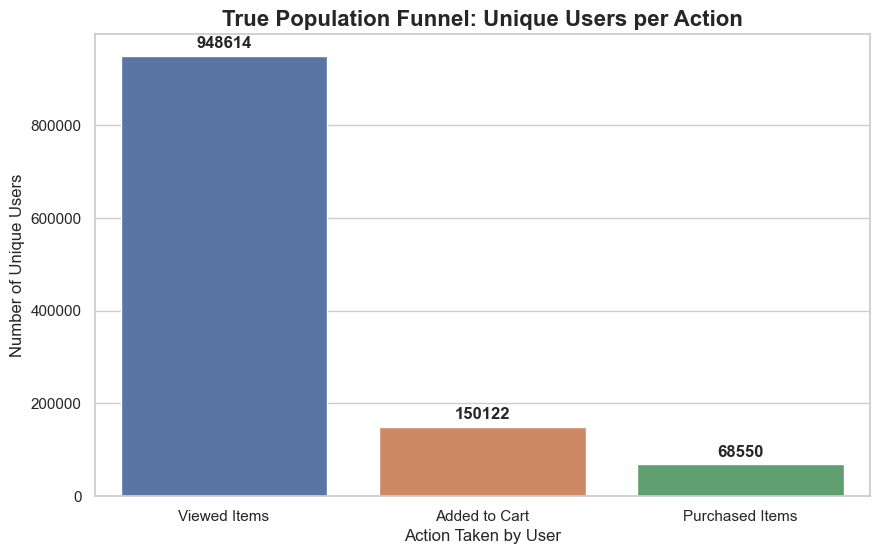

------------------------------------------------------------
 TRUE POPULATION CONVERSION METRICS 
------------------------------------------------------------
1. View-to-Cart Conversion : 15.83% (Kitne log cart tak pahuche)
2. Cart-to-Purchase Rate   : 45.66% (Inhone cart banaya aur kharida)
3. CART ABANDONMENT RATE   : 54.34% (Inhone cart me daala par kharida nahi!)
4. Final Overall Conversion: 7.23% (Total success rate)
------------------------------------------------------------


In [4]:
# STEP 1: Teeno Actions ke liye Unique Users nikalna
unique_viewers = final_df[final_df['event_type'] == 'view']['user_id'].nunique()
unique_carters = final_df[final_df['event_type'] == 'cart']['user_id'].nunique()
unique_buyers = final_df[final_df['event_type'] == 'purchase']['user_id'].nunique()

# STEP 2: Graph ke liye DataFrame banana
population_funnel = pd.DataFrame({
    'Action Taken by User': ['Viewed Items', 'Added to Cart', 'Purchased Items'],
    'Unique Users Count': [unique_viewers, unique_carters, unique_buyers]
})

# STEP 3: Graph Plot Karna
plt.figure(figsize=(10, 6))
# Colors: Blue (View), Orange (Cart), Green (Purchase)
ax = sns.barplot(x='Action Taken by User', y='Unique Users Count', data=population_funnel, palette=['#4C72B0', '#DD8452', '#55A868'])

plt.title('True Population Funnel: Unique Users per Action', fontsize=16, fontweight='bold')
plt.ylabel('Number of Unique Users', fontsize=12)

# Bars ke upar exact number likhna
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.0f'), 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points',
                fontsize=12, fontweight='bold')

plt.show()

# STEP 4: Deep Business Metrics Print Karna
print("-" * 60)
print(" TRUE POPULATION CONVERSION METRICS ")
print("-" * 60)
if unique_viewers > 0:
    print(f"1. View-to-Cart Conversion : {(unique_carters / unique_viewers) * 100:.2f}% (Kitne log cart tak pahuche)")
if unique_carters > 0:
    print(f"2. Cart-to-Purchase Rate   : {(unique_buyers / unique_carters) * 100:.2f}% (Inhone cart banaya aur kharida)")
    print(f"3. CART ABANDONMENT RATE   : {(1 - (unique_buyers / unique_carters)) * 100:.2f}% (Inhone cart me daala par kharida nahi!)")
if unique_viewers > 0:
    print(f"4. Final Overall Conversion: {(unique_buyers / unique_viewers) * 100:.2f}% (Total success rate)")
print("-" * 60)

In [5]:
final_df.head(4)

,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session,category_code_filled,brand_filled,hour
0,2019-11-02 13:29:04+00:00,view,12300059,2053013556311359947,construction.tools.drill,bosch,69.17,513196170,00000510-834a-498a-9bed-561a90c5125e,construction.tools.drill,bosch,13
1,2019-11-01 19:06:53+00:00,view,1002544,2053013555631882655,electronics.smartphone,apple,458.25,514001239,000009c4-a1dd-4764-87d9-24f3d7e43c4f,electronics.smartphone,apple,19
2,2019-11-01 19:07:11+00:00,view,1002544,2053013555631882655,electronics.smartphone,apple,458.25,514001239,000009c4-a1dd-4764-87d9-24f3d7e43c4f,electronics.smartphone,apple,19
3,2019-11-01 19:08:13+00:00,view,1004659,2053013555631882655,electronics.smartphone,samsung,716.76,514001239,000009c4-a1dd-4764-87d9-24f3d7e43c4f,electronics.smartphone,samsung,19


In [4]:
final_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6727451 entries, 0 to 6727450
Data columns (total 12 columns):
 #   Column                Dtype  
---  ------                -----  
 0   event_time            str    
 1   event_type            str    
 2   product_id            int64  
 3   category_id           int64  
 4   category_code         str    
 5   brand                 str    
 6   price                 float64
 7   user_id               int64  
 8   user_session          str    
 9   category_code_filled  str    
 10  brand_filled          str    
 11  hour                  int64  
dtypes: float64(1), int64(4), str(7)
memory usage: 615.9 MB


In [5]:
final_df['event_time'] = pd.to_datetime(final_df['event_time'])

In [6]:
final_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6727451 entries, 0 to 6727450
Data columns (total 12 columns):
 #   Column                Dtype              
---  ------                -----              
 0   event_time            datetime64[us, UTC]
 1   event_type            str                
 2   product_id            int64              
 3   category_id           int64              
 4   category_code         str                
 5   brand                 str                
 6   price                 float64            
 7   user_id               int64              
 8   user_session          str                
 9   category_code_filled  str                
 10  brand_filled          str                
 11  hour                  int64              
dtypes: datetime64[us, UTC](1), float64(1), int64(4), str(6)
memory usage: 615.9 MB


In [7]:
session_time = final_df.groupby('user_session').agg(
    start_time=('event_time', 'min'),
    end_time=('event_time', 'max')
)

In [8]:
session_time

,start_time,end_time
user_session,,
00000510-834a-498a-9bed-561a90c5125e,2019-11-02 13:29:04+00:00,2019-11-02 13:29:04+00:00
000009c4-a1dd-4764-87d9-24f3d7e43c4f,2019-11-01 19:06:53+00:00,2019-11-01 19:14:58+00:00
0000189b-6d2d-45bc-a65c-3a9d94e330a4,2019-11-23 20:03:08+00:00,2019-11-23 20:03:08+00:00
000029a6-1986-4a71-8139-53669c1adaba,2019-11-16 11:18:37+00:00,2019-11-16 11:20:50+00:00
00003dca-5a5a-4af2-86ef-9851ceb02a2b,2019-11-12 09:36:38+00:00,2019-11-12 09:37:34+00:00
...,...,...
ffffb94a-cea4-429d-ba4a-7e47a6f28171,2019-11-24 08:21:02+00:00,2019-11-24 08:34:23+00:00
ffffb9ea-87d1-4f3d-b107-91b1bb087d36,2019-11-16 19:03:20+00:00,2019-11-16 19:06:17+00:00
ffffcdf8-f820-4b22-acee-d8c425b624fc,2019-11-19 12:03:27+00:00,2019-11-19 12:03:27+00:00


In [11]:
# Duration minutes mein calculate karna
session_time['duration_minutes'] = (session_time['end_time'] - session_time['start_time']).dt.total_seconds() / 60


In [12]:
session_time

,start_time,end_time,duration_minutes
user_session,,,
00000510-834a-498a-9bed-561a90c5125e,2019-11-02 13:29:04+00:00,2019-11-02 13:29:04+00:00,0.000000
000009c4-a1dd-4764-87d9-24f3d7e43c4f,2019-11-01 19:06:53+00:00,2019-11-01 19:14:58+00:00,8.083333
0000189b-6d2d-45bc-a65c-3a9d94e330a4,2019-11-23 20:03:08+00:00,2019-11-23 20:03:08+00:00,0.000000
000029a6-1986-4a71-8139-53669c1adaba,2019-11-16 11:18:37+00:00,2019-11-16 11:20:50+00:00,2.216667
00003dca-5a5a-4af2-86ef-9851ceb02a2b,2019-11-12 09:36:38+00:00,2019-11-12 09:37:34+00:00,0.933333
...,...,...,...
ffffb94a-cea4-429d-ba4a-7e47a6f28171,2019-11-24 08:21:02+00:00,2019-11-24 08:34:23+00:00,13.350000
ffffb9ea-87d1-4f3d-b107-91b1bb087d36,2019-11-16 19:03:20+00:00,2019-11-16 19:06:17+00:00,2.950000
ffffcdf8-f820-4b22-acee-d8c425b624fc,2019-11-19 12:03:27+00:00,2019-11-19 12:03:27+00:00,0.000000


In [13]:
session_time[session_time['duration_minutes']==0]

,start_time,end_time,duration_minutes
user_session,,,
00000510-834a-498a-9bed-561a90c5125e,2019-11-02 13:29:04+00:00,2019-11-02 13:29:04+00:00,0.0
0000189b-6d2d-45bc-a65c-3a9d94e330a4,2019-11-23 20:03:08+00:00,2019-11-23 20:03:08+00:00,0.0
000077fb-5f32-4a86-a179-2bbf8c34e9d8,2019-11-20 13:50:06+00:00,2019-11-20 13:50:06+00:00,0.0
0000ae8f-570d-4a89-9690-6f22050b8175,2019-11-08 16:36:16+00:00,2019-11-08 16:36:16+00:00,0.0
0000be71-fe05-4b44-af8e-e8de041095d2,2019-11-03 03:24:09+00:00,2019-11-03 03:24:09+00:00,0.0
...,...,...,...
ffff6769-207a-4cc1-a703-aba733aa0df1,2019-11-11 04:27:32+00:00,2019-11-11 04:27:32+00:00,0.0
ffffa9a9-336a-49f8-8ff3-8ebb37f00243,2019-11-14 15:08:28+00:00,2019-11-14 15:08:28+00:00,0.0
ffffcdf8-f820-4b22-acee-d8c425b624fc,2019-11-19 12:03:27+00:00,2019-11-19 12:03:27+00:00,0.0


In [16]:
cart_sessions=set(final_df[final_df['event_type']=='cart']['user_session'])
purchase_sessions=set(final_df[final_df['event_type']=='purchase']['user_session'])
print(len(cart_sessions))
print(len(purchase_sessions))

174036
77447


{'4bd0ad3f-237b-41d5-93a1-2ecdf2bb9ec0',
 '9bf65c12-4008-42a1-ba54-007ff1ec0743',
 'fb04656f-5385-a92f-335b-753de84b8472',
 'cb23c4d0-bf01-4d70-b5fd-1da37ef942a8',
 '58620dc7-db12-4608-bec3-dcac3e9500aa',
 '09948eab-4eb7-41e3-a234-27865bfbb497',
 'ca46f1bc-7c28-4864-bae3-6706dd60d283',
 '05a1daab-6aba-4c0b-bcfb-de361651b8b6',
 '03e202c1-4802-4fb2-8056-519e380cf219',
 'f9fcb7dc-4ca2-4796-b6c6-3e0438b2d795',
 '47e2645c-5f60-42be-8b34-2e9ddfaa2c96',
 '5530096a-04f6-48b5-9245-d96c046a1948',
 '8d38978a-c834-4f52-a1bd-bfef630f4062',
 '1d4520c3-0f1f-488f-8fdf-7eb0fbcc0cac',
 '5c3b33fe-a6cb-415c-81bf-0e4dab346ab0',
 'bdc8ed30-6a52-4539-8ed8-cca660db46fa',
 'e412d56f-6a11-4952-ad26-22c2ad770125',
 'e6d8b8bc-4e23-47e8-8d0b-2d432607f981',
 '0b0858f4-3c81-46c5-8ca4-db974b854e99',
 '972ac2c5-dad1-4384-b155-a35d371afc48',
 '7b2e7a31-f8a4-4d6d-85f1-09d3326b7a0d',
 'be8be41c-2244-4192-93a7-7aad14ab827a',
 '107f0e06-5d38-470b-9d17-9cd7c9f5aac1',
 '01435e67-f538-4424-92bf-a9986ec7522c',
 '586d2bfa-01e5-

In [19]:
session_time['has_cart'] = session_time.index.isin(cart_sessions)
session_time['has_purchase'] = session_time.index.isin(purchase_sessions)

In [20]:
session_time.head(10)

,start_time,end_time,duration_minutes,has_cart,has_purchase
user_session,,,,,
00000510-834a-498a-9bed-561a90c5125e,2019-11-02 13:29:04+00:00,2019-11-02 13:29:04+00:00,0.000000,False,False
000009c4-a1dd-4764-87d9-24f3d7e43c4f,2019-11-01 19:06:53+00:00,2019-11-01 19:14:58+00:00,8.083333,False,False
0000189b-6d2d-45bc-a65c-3a9d94e330a4,2019-11-23 20:03:08+00:00,2019-11-23 20:03:08+00:00,0.000000,False,False
000029a6-1986-4a71-8139-53669c1adaba,2019-11-16 11:18:37+00:00,2019-11-16 11:20:50+00:00,2.216667,False,False
00003dca-5a5a-4af2-86ef-9851ceb02a2b,2019-11-12 09:36:38+00:00,2019-11-12 09:37:34+00:00,0.933333,False,False
00004022-c43d-4223-b5ad-da2b0e59b84f,2019-11-17 18:41:08+00:00,2019-11-17 18:45:23+00:00,4.250000,False,False
000077fb-5f32-4a86-a179-2bbf8c34e9d8,2019-11-20 13:50:06+00:00,2019-11-20 13:50:06+00:00,0.000000,False,False
00007d1a-aa00-4a01-b03c-879973251c53,2019-11-16 13:08:14+00:00,2019-11-16 13:10:04+00:00,1.833333,False,False
0000a101-4e26-488a-85e9-f666baec0fc5,2019-11-28 03:22:09+00:00,2019-11-28 03:22:57+00:00,0.800000,False,False


In [21]:
# STEP 3: Time Buckets banana (0-1 min, 1-5 mins, etc.)
bins = [-1, 1, 5, 15, 30, 60, np.inf]
labels = ['< 1 min', '1-5 mins', '5-15 mins', '15-30 mins', '30-60 mins', '60+ mins']
session_time['time_bucket'] = pd.cut(session_time['duration_minutes'], bins=bins, labels=labels)

In [22]:
session_time.head(10)


,start_time,end_time,duration_minutes,has_cart,has_purchase,time_bucket
user_session,,,,,,
00000510-834a-498a-9bed-561a90c5125e,2019-11-02 13:29:04+00:00,2019-11-02 13:29:04+00:00,0.000000,False,False,< 1 min
000009c4-a1dd-4764-87d9-24f3d7e43c4f,2019-11-01 19:06:53+00:00,2019-11-01 19:14:58+00:00,8.083333,False,False,5-15 mins
0000189b-6d2d-45bc-a65c-3a9d94e330a4,2019-11-23 20:03:08+00:00,2019-11-23 20:03:08+00:00,0.000000,False,False,< 1 min
000029a6-1986-4a71-8139-53669c1adaba,2019-11-16 11:18:37+00:00,2019-11-16 11:20:50+00:00,2.216667,False,False,1-5 mins
00003dca-5a5a-4af2-86ef-9851ceb02a2b,2019-11-12 09:36:38+00:00,2019-11-12 09:37:34+00:00,0.933333,False,False,< 1 min
00004022-c43d-4223-b5ad-da2b0e59b84f,2019-11-17 18:41:08+00:00,2019-11-17 18:45:23+00:00,4.250000,False,False,1-5 mins
000077fb-5f32-4a86-a179-2bbf8c34e9d8,2019-11-20 13:50:06+00:00,2019-11-20 13:50:06+00:00,0.000000,False,False,< 1 min
00007d1a-aa00-4a01-b03c-879973251c53,2019-11-16 13:08:14+00:00,2019-11-16 13:10:04+00:00,1.833333,False,False,1-5 mins
0000a101-4e26-488a-85e9-f666baec0fc5,2019-11-28 03:22:09+00:00,2019-11-28 03:22:57+00:00,0.800000,False,False,< 1 min


In [23]:
# STEP 4: Har bucket ka Cart aur Purchase Percentage (Conversion Rate) calculate karna
bucket_stats = session_time.groupby('time_bucket', observed=True).agg(
    total_sessions=('duration_minutes', 'count'),
    cart_count=('has_cart', 'sum'),
    purchase_count=('has_purchase', 'sum')
)


In [24]:
bucket_stats.head(10)

,total_sessions,cart_count,purchase_count
time_bucket,,,
< 1 min,692192,29267,6337
1-5 mins,354720,65849,35896
5-15 mins,211166,46893,23073
15-30 mins,67714,17732,7241
30-60 mins,30851,8827,3115
60+ mins,21579,5468,1785


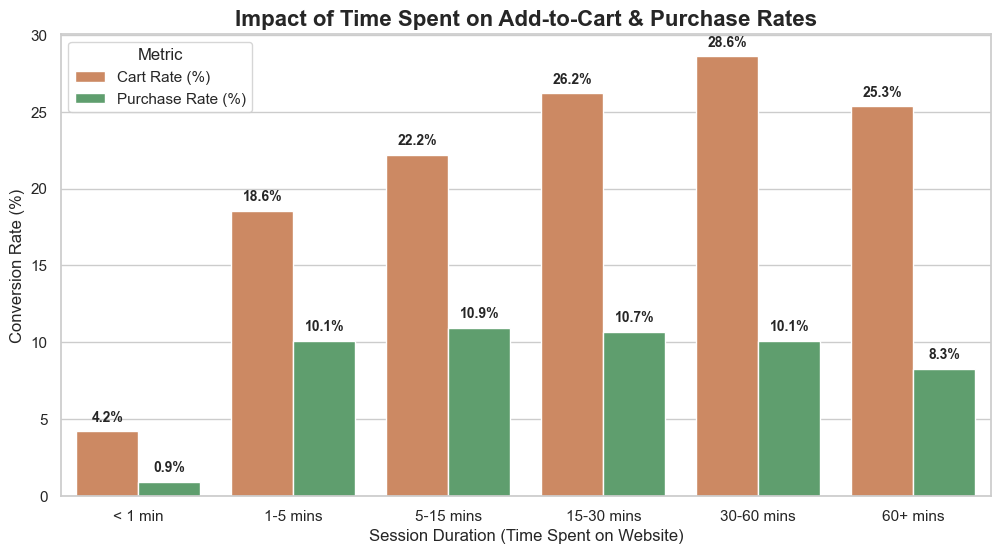

In [25]:

# STEP 4: Har bucket ka Cart aur Purchase Percentage (Conversion Rate) calculate karna
bucket_stats = session_time.groupby('time_bucket', observed=True).agg(
    total_sessions=('duration_minutes', 'count'),
    cart_count=('has_cart', 'sum'),
    purchase_count=('has_purchase', 'sum')
)

# Percentages nikalna
bucket_stats['Cart Rate (%)'] = (bucket_stats['cart_count'] / bucket_stats['total_sessions']) * 100
bucket_stats['Purchase Rate (%)'] = (bucket_stats['purchase_count'] / bucket_stats['total_sessions']) * 100
bucket_stats = bucket_stats.reset_index()

# Graph ke liye data ko reshape karna (Melting)
plot_data = pd.melt(bucket_stats, id_vars='time_bucket', 
                    value_vars=['Cart Rate (%)', 'Purchase Rate (%)'], 
                    var_name='Metric', value_name='Rate')

# STEP 5: Graph Plot Karna
plt.figure(figsize=(12, 6))
ax = sns.barplot(x='time_bucket', y='Rate', hue='Metric', data=plot_data, palette=['#DD8452', '#55A868'])

plt.title('Impact of Time Spent on Add-to-Cart & Purchase Rates', fontsize=16, fontweight='bold')
plt.xlabel('Session Duration (Time Spent on Website)', fontsize=12)
plt.ylabel('Conversion Rate (%)', fontsize=12)

# Bars ke upar exact percentage likhna
for p in ax.patches:
    height = p.get_height()
    if height > 0: # Sirf un bars par number likho jinki height 0 se zyada hai
        ax.annotate(f'{height:.1f}%', 
                    (p.get_x() + p.get_width() / 2., height), 
                    ha='center', va='bottom', 
                    xytext=(0, 5), 
                    textcoords='offset points',
                    fontsize=10, fontweight='bold')

plt.show()

In [27]:
bucket_stats

,time_bucket,total_sessions,cart_count,purchase_count,Cart Rate (%),Purchase Rate (%)
0,< 1 min,692192,29267,6337,4.228162,0.915497
1,1-5 mins,354720,65849,35896,18.563656,10.119531
2,5-15 mins,211166,46893,23073,22.206700,10.926475
3,15-30 mins,67714,17732,7241,26.186608,10.693505
4,30-60 mins,30851,8827,3115,28.611714,10.096917
5,60+ mins,21579,5468,1785,25.339450,8.271931


PRICE_Sensitivity:

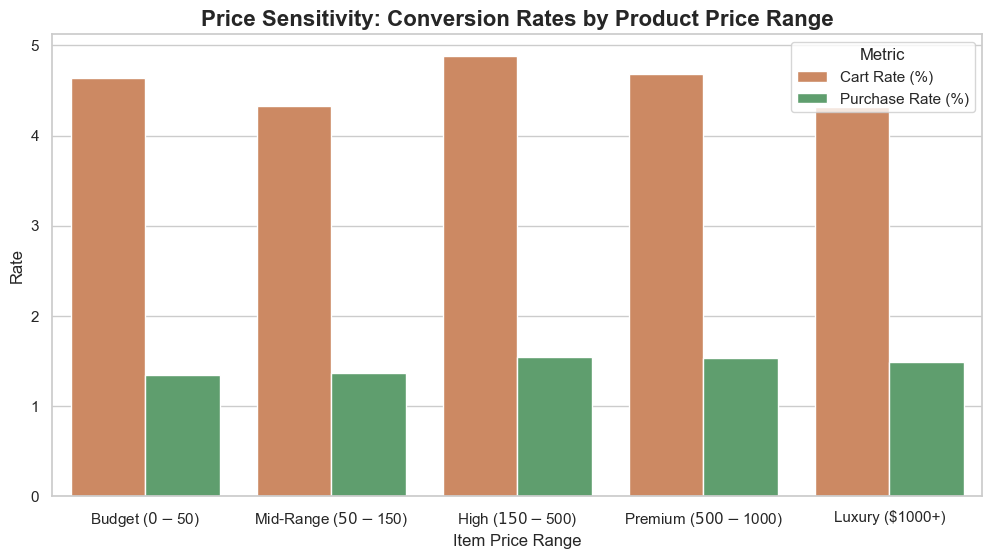

In [30]:
# STEP 1: Price Buckets Banana
# Hum prices ko logical ranges mein divide kar rahe hain (e-commerce standard)
bins = [0, 50, 150, 500, 1000, np.inf]
labels = ['Budget ($0-$50)', 'Mid-Range ($50-$150)', 'High ($150-$500)', 'Premium ($500-$1000)', 'Luxury ($1000+)']

# Naya column add kar rahe hain price buckets ke liye
final_df['price_bucket'] = pd.cut(final_df['price'], bins=bins, labels=labels)

# STEP 2: Har Price Bucket mein View, Cart, aur Purchase count karna
price_stats = final_df.groupby(['price_bucket', 'event_type'], observed=True).size().unstack(fill_value=0)

# STEP 3: Conversion Rates Calculate Karna (Out of total views in that bucket)
price_stats['Cart Rate (%)'] = (price_stats['cart'] / price_stats['view']) * 100
price_stats['Purchase Rate (%)'] = (price_stats['purchase'] / price_stats['view']) * 100
price_stats = price_stats.reset_index()

# Graph ke liye data ko reshape karna
plot_data = pd.melt(price_stats, id_vars='price_bucket', 
                    value_vars=['Cart Rate (%)', 'Purchase Rate (%)'], 
                    var_name='Metric', value_name='Rate')

# STEP 4: Graph Plot Karna
plt.figure(figsize=(12, 6))
ax = sns.barplot(x='price_bucket', y='Rate', hue='Metric', data=plot_data, palette=['#DD8452', '#55A868'])

plt.title('Price Sensitivity: Conversion Rates by Product Price Range', fontsize=16, fontweight='bold')
plt.xlabel('Item Price Range', fontsize=12)
plt.show()

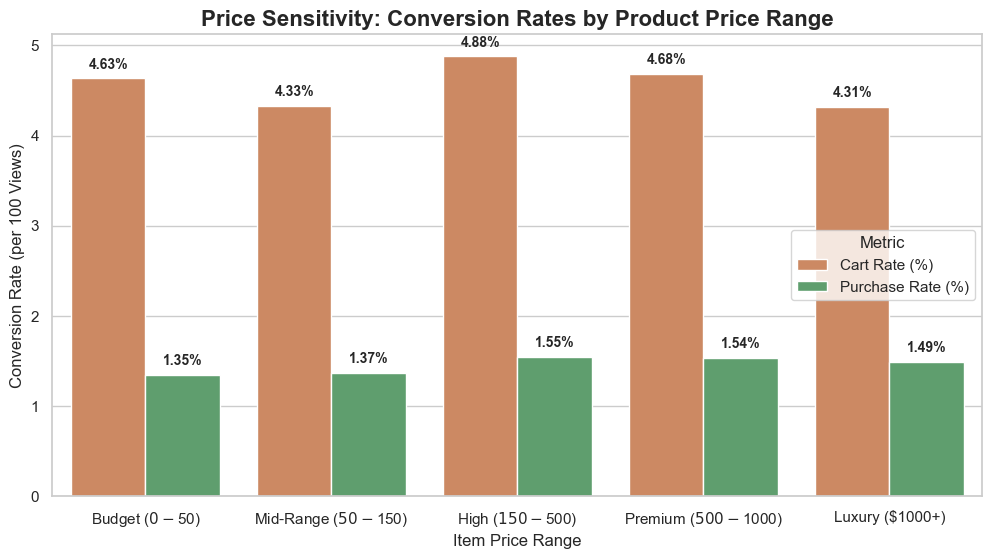

In [31]:
# STEP 1: Price Buckets Banana
# Hum prices ko logical ranges mein divide kar rahe hain (e-commerce standard)
bins = [0, 50, 150, 500, 1000, np.inf]
labels = ['Budget ($0-$50)', 'Mid-Range ($50-$150)', 'High ($150-$500)', 'Premium ($500-$1000)', 'Luxury ($1000+)']

# Naya column add kar rahe hain price buckets ke liye
final_df['price_bucket'] = pd.cut(final_df['price'], bins=bins, labels=labels)

# STEP 2: Har Price Bucket mein View, Cart, aur Purchase count karna
price_stats = final_df.groupby(['price_bucket', 'event_type'], observed=True).size().unstack(fill_value=0)

# STEP 3: Conversion Rates Calculate Karna (Out of total views in that bucket)
price_stats['Cart Rate (%)'] = (price_stats['cart'] / price_stats['view']) * 100
price_stats['Purchase Rate (%)'] = (price_stats['purchase'] / price_stats['view']) * 100
price_stats = price_stats.reset_index()

# Graph ke liye data ko reshape karna
plot_data = pd.melt(price_stats, id_vars='price_bucket', 
                    value_vars=['Cart Rate (%)', 'Purchase Rate (%)'], 
                    var_name='Metric', value_name='Rate')

# STEP 4: Graph Plot Karna
plt.figure(figsize=(12, 6))
ax = sns.barplot(x='price_bucket', y='Rate', hue='Metric', data=plot_data, palette=['#DD8452', '#55A868'])

plt.title('Price Sensitivity: Conversion Rates by Product Price Range', fontsize=16, fontweight='bold')
plt.xlabel('Item Price Range', fontsize=12)
plt.ylabel('Conversion Rate (per 100 Views)', fontsize=12)

# Bars ke upar exact percentage likhna
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{height:.2f}%', 
                    (p.get_x() + p.get_width() / 2., height), 
                    ha='center', va='bottom', 
                    xytext=(0, 5), 
                    textcoords='offset points',
                    fontsize=10, fontweight='bold')

plt.show()

In [32]:
price_stats

event_type,price_bucket,cart,purchase,view,Cart Rate (%),Purchase Rate (%)
0,Budget ($0-$50),52787,15333,1139517,4.632401,1.345570
1,Mid-Range ($50-$150),78029,24645,1803437,4.326683,1.366557
2,High ($150-$500),112539,35702,2306149,4.879954,1.548122
3,Premium ($500-$1000),35704,11712,762513,4.682412,1.535974
4,Luxury ($1000+),13488,4665,312585,4.314986,1.492394
